In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.utils.assemblies import hg19
from cns.process.imputation import get_nan_segs
from cns.process.binning import get_breakpoints, breaks_to_segments, bin_by_segments
from cns.analyze.labels import plot_x_ticks, plot_cytobands
from cns.process.segments import add_seg_info, breaks_to_segments, genome_to_segments, segment_difference, tuples_to_segments
from cns.data_utils import load_cns_out

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
data = {
    "PCAWG" : load_cns_out("PCAWG_cns_fill.tsv"),
    "TCGA": load_cns_out("TCGA_hg19_cns_fill.tsv"),
    "TRACERx": load_cns_out("TRACERx_cns_fill.tsv"),
}
colors = ["cyan", "purple", "green"]

In [3]:
cyto_breaks = get_breakpoints("cytobands")
cyto_segments = breaks_to_segments(cyto_breaks)
nans = {k: add_seg_info(get_nan_segs(v)) for k, v in data.items()}
nans["PCAWG"].head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,mid,cum_mid,total_cn
43,SP1003,chr1,249250620,249250621,NaN,NaN,1,249250620,249250620,NaN
175,SP1003,chr2,0,20015,NaN,NaN,20015,10007,249260628,NaN
177,SP1003,chr2,89857499,96799999,NaN,NaN,6942500,93328749,342579370,NaN
179,SP1003,chr2,242999968,243199373,NaN,NaN,199405,243099670,492350291,NaN
192,SP1003,chr3,0,100073,NaN,NaN,100073,50036,492500030,NaN


# NaNs across samples

In [19]:
def plot_nan_hist(ax, nans, genome_length, color, label, query=None):
    if query:
        nans = nans.query(query)
    lengths = nans.groupby("sample_id")["length"].sum()

    # plot histogram of lengths / genome_length
    ax.hist(1 - (lengths / genome_length), bins=np.linspace(.8, 1, 80), alpha=0.5, color=color, label=label, density=True)

    ax.legend()

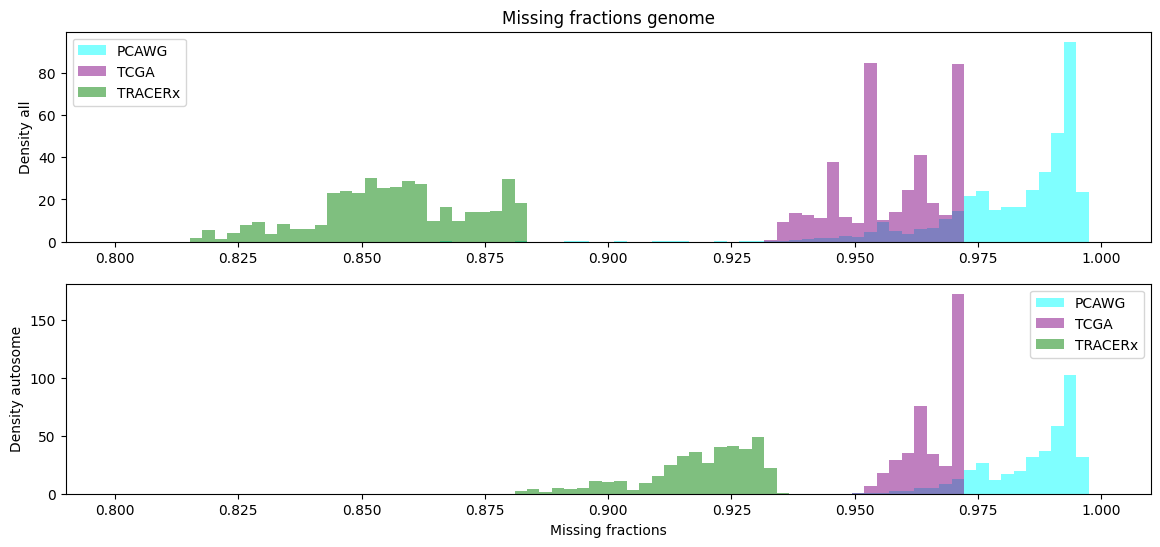

In [20]:
fig, axs = plt.subplots(2, figsize=(14, 6))
yaxes = ["Density all", "Density autosome"]
queries = ["", "chrom != 'chrX' and chrom != 'chrY'"]
for j in range(2):
    for i, (k, v) in enumerate(nans.items()):
        plot_nan_hist(axs[j], v, hg19.gen_len, color=colors[i], label=k, query=queries[j])
        axs[j].set_ylabel(yaxes[j])
axs[0].set_title("Missing fractions genome")
axs[1].set_xlabel("Missing fractions");

# No gap NaNs

Binning chr (65471/65471)
Binning chr (231612/231612)
Binning chr (33691/33691)


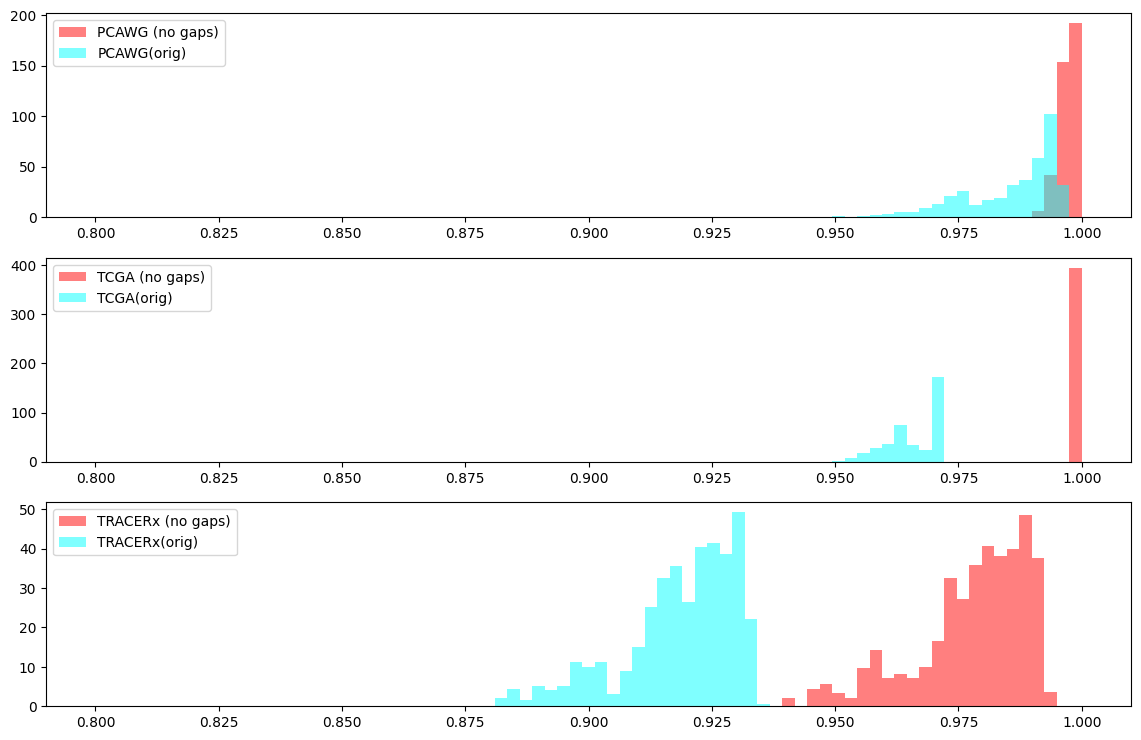

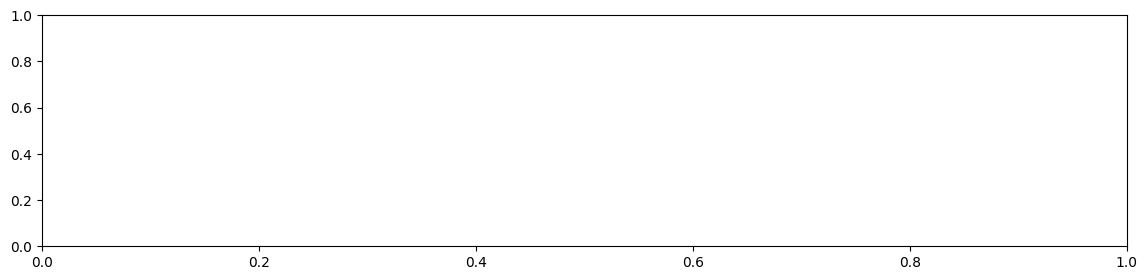

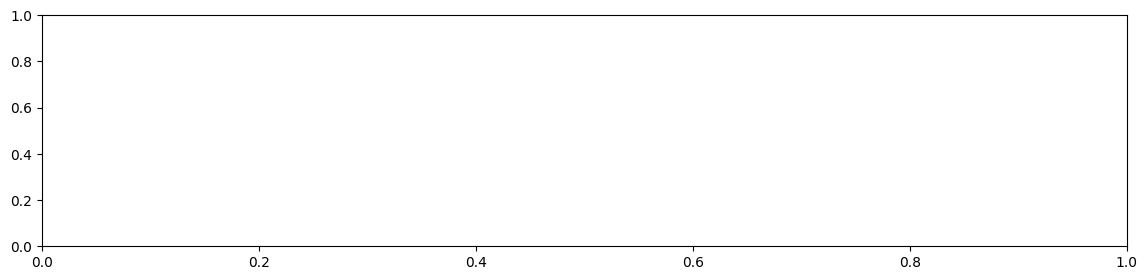

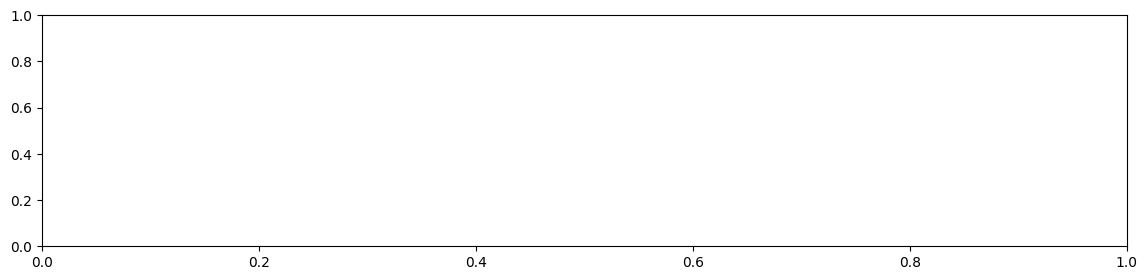

In [26]:
fig, axs = plt.subplots(3, figsize=(14, 9))
breaks = hg19.gaps
gap_segs = tuples_to_segments(breaks)
sel_segs = segment_difference(genome_to_segments(), gap_segs)
no_sex_q = "chrom != 'chrX' and chrom != 'chrY'"
for i, (k, v) in enumerate(nans.items()):
	sel_regs = bin_by_segments(v, sel_segs, fun_type=None)
	nans_sel = add_seg_info(get_nan_segs(sel_regs))
	plot_nan_hist(axs[i], nans_sel, hg19.gen_len, color="red", label=k + " (no gaps)", query=no_sex_q)
	plot_nan_hist(axs[i], v, hg19.gen_len, color="cyan", label=k + " (orig)", query=no_sex_q)